# Robust Drug Allergy Prediction System

This notebook applies the full ML requirements:

- Handles imbalanced data using class weighting and oversampling.
- Splits data into train, validation, and test sets.
- Uses K-Fold Cross-Validation on the training set.
- Tunes the decision threshold on the validation set.
- Evaluates the final selected model on the test set only.
- Compares Logistic Regression, Random Forest, and LightGBM Gradient Boosting.
- Shows accuracy, recall, precision, F1/F2, ROC-AUC, PR-AUC, and confusion matrix.
- Adds feature importance, SHAP-based explanation support, multi-drug prediction, and monitoring/drift alerts.

**Important safety note:** This is for ML/project work only. It is not medical advice. Real allergy/drug substitution decisions must be checked by a licensed medical professional.

In [52]:
# If you run this in Colab and something is missing, uncomment this line:
# !pip install -q imbalanced-learn lightgbm shap joblib

In [53]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Load and inspect the dataset

The target column is `allergic_to_drug`. The positive class is `1`, meaning the drug is predicted as allergic/allergenic.

In [54]:
possible_paths = [
    Path("openfda_drug_allergy_dataset(1).csv"),
    Path("openfda_drug_allergy_dataset.csv"),
    Path("/content/openfda_drug_allergy_dataset(1).csv"),
    Path("/content/openfda_drug_allergy_dataset.csv"),
    Path("/mnt/data/openfda_drug_allergy_dataset(1).csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV file not found. Put the dataset in the same folder as this notebook, "
        "or upload it to Colab as openfda_drug_allergy_dataset(1).csv."
    )

raw_data = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH)
print("Shape:", raw_data.shape)
raw_data.head()

Dataset path: openfda_drug_allergy_dataset.csv
Shape: (4220, 12)


,age_years,gender,gender_code,weight_kg,drug_name,drug_role,active_ingredients,reactions,previous_allergic_reactions,has_previous_allergy,is_serious,allergic_to_drug
0,40.0,male,1,79.45,Duragesic-100,suspect,NaN,DRUG ADMINISTRATION ERROR; OVERDOSE,none,0,1,0
1,55.0,female,2,67.12,Boniva,suspect,NaN,Vomiting; Diarrhoea; Arthralgia; Headache,none,0,1,0
2,55.0,female,2,67.12,Ibuprofen,suspect,IBUPROFEN,Dyspepsia; Renal impairment,none,0,1,0
3,40.0,male,1,79.45,Lyrica,suspect,PREGABALIN,Drug ineffective,none,0,0,0
4,55.0,female,2,67.12,Doxycycline Hyclate,suspect,DOXYCYCLINE HYCLATE; DOXYCYCLINE ANHYDROUS,Drug hypersensitivity,none,0,0,1


In [55]:
print("Missing values:")
display(raw_data.isna().sum())

print("Target distribution:")
display(raw_data["allergic_to_drug"].value_counts())
display(raw_data["allergic_to_drug"].value_counts(normalize=True).rename("ratio"))

Missing values:


,0
age_years,0
gender,0
gender_code,0
weight_kg,0
drug_name,1
drug_role,0
active_ingredients,1180
reactions,0
previous_allergic_reactions,0
has_previous_allergy,0


Target distribution:


,count
allergic_to_drug,
0,3855
1,365


,ratio
allergic_to_drug,
0,0.913507
1,0.086493


## 2. Basic cleaning

Only simple cleaning is done before splitting. Encoding, scaling, vectorizing, and oversampling are inside pipelines so they are fitted only on training data. This helps avoid data leakage.

In [56]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Normalize text columns.
    text_cols = df.select_dtypes(include=["object"]).columns
    for col in text_cols:
        df[col] = df[col].fillna("unknown").astype(str).str.lower().str.strip()

    # Keep numeric columns numeric.
    for col in ["age_years", "weight_kg", "gender_code", "has_previous_allergy", "is_serious", "allergic_to_drug"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

data = clean_data(raw_data)
TARGET = "allergic_to_drug"
X = data.drop(columns=[TARGET])
y = data[TARGET].astype(int)

print("Cleaned shape:", data.shape)
print("Positive class ratio:", round(y.mean(), 4))

Cleaned shape: (4220, 12)
Positive class ratio: 0.0865


## 3. Proper Train / Validation / Test split

- Training set: used to train models and run K-Fold CV.
- Validation set: used for threshold tuning and model selection.
- Test set: used only once for the final evaluation.

In [57]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

# 0.17647 of the remaining 85% gives about 15% validation overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.17647,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "positive ratio:", round(y_train.mean(), 4))
print("Validation:", X_val.shape, "positive ratio:", round(y_val.mean(), 4))
print("Test:", X_test.shape, "positive ratio:", round(y_test.mean(), 4))

Train: (2954, 11) positive ratio: 0.0863
Validation: (633, 11) positive ratio: 0.0869
Test: (633, 11) positive ratio: 0.0869


## 4. Preprocessing pipeline

Text columns are vectorized using TF-IDF. Categorical columns are one-hot encoded. Numeric columns are imputed and scaled.

`reactions` can make the score very high because allergy-like words may appear there. Keep it only if your goal is to classify adverse-event reports. If your goal is to predict allergy risk before giving a drug, set `USE_REACTION_FEATURES = False`.

In [58]:
USE_REACTION_FEATURES = True

numeric_features = [
    "age_years",
    "weight_kg",
    "gender_code",
    "has_previous_allergy",
    "is_serious",
]

categorical_features = [
    "gender",
    "drug_role",
    "previous_allergic_reactions",
]

text_features = ["drug_name", "active_ingredients"]
if USE_REACTION_FEATURES:
    text_features.append("reactions")

# Keep only columns that exist.
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in categorical_features if c in X.columns]
text_features = [c for c in text_features if c in X.columns]

transformers = [
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        numeric_features,
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore", min_frequency=5),
        categorical_features,
    ),
]

# Different max_features by column to keep training fast and stable.
tfidf_limits = {
    "drug_name": 100,
    "active_ingredients": 100,
    "reactions": 200,
}

for col in text_features:
    transformers.append(
        (
            f"{col}_tfidf",
            TfidfVectorizer(
                max_features=tfidf_limits.get(col, 100),
                ngram_range=(1, 2),
                min_df=2,
            ),
            col,
        )
    )

preprocessor = ColumnTransformer(transformers, sparse_threshold=0.7)

## 5. Candidate models

We compare three model families:

1. Logistic Regression with class weighting.
2. Logistic Regression with oversampling.
3. Random Forest with class weighting.
4. LightGBM Gradient Boosting with class weighting.

The positive class is rare, so class weighting and oversampling help the model care more about allergy cases.

In [59]:
neg_count, pos_count = np.bincount(y_train)
scale_pos_weight = neg_count / pos_count

models = {
    "Logistic Regression - class_weight": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            C=1.0,
            random_state=RANDOM_STATE,
        )),
    ]),

    "Logistic Regression - oversampling": ImbPipeline([
        ("prep", preprocessor),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            C=1.0,
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest - class_weight": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=80,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),

    "LightGBM Gradient Boosting - class_weight": Pipeline([
        ("prep", preprocessor),
        ("clf", LGBMClassifier(
            n_estimators=50,
            num_leaves=15,
            learning_rate=0.10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1,
            force_col_wise=True,
        )),
    ]),
}

## 6. K-Fold Cross-Validation on the training set

K-Fold CV is done only on the training set. It gives a more robust estimate before validation tuning.

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "f2": make_scorer(fbeta_score, beta=2),
}

cv_rows = []
for name, model in models.items():
    print(f"Running CV for: {name}")
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        row[f"cv_{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"cv_{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("cv_recall_mean", ascending=False)
display(cv_results)

Running CV for: Logistic Regression - class_weight
Running CV for: Logistic Regression - oversampling
Running CV for: Random Forest - class_weight
Running CV for: LightGBM Gradient Boosting - class_weight


,model,cv_accuracy_mean,cv_accuracy_std,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_precision_std,cv_f1_mean,cv_f1_std,cv_f2_mean,cv_f2_std
3,LightGBM Gradient Boosting - class_weight,0.995262,0.002707,0.980392,0.017538,0.965448,0.018455,0.972775,0.015495,0.977310,0.016124
1,Logistic Regression - oversampling,0.983752,0.004486,0.952941,0.048980,0.875675,0.052543,0.910352,0.023059,0.934854,0.033156
0,Logistic Regression - class_weight,0.981043,0.002907,0.941176,0.044713,0.857495,0.040673,0.895580,0.014709,0.921914,0.028339
2,Random Forest - class_weight,0.990184,0.005063,0.929412,0.031859,0.959081,0.051592,0.942816,0.027741,0.934442,0.025842


## 7. Validation tuning

The default classification threshold is `0.50`, but for allergy detection we prefer high recall. This code searches thresholds and chooses the best threshold that keeps recall high while still keeping accuracy strong.

In [61]:
def evaluate_at_threshold(y_true, y_prob, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def tune_threshold(y_true, y_prob, min_recall: float = 0.80) -> tuple[float, pd.DataFrame]:
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        rows.append(evaluate_at_threshold(y_true, y_prob, float(threshold)))

    curve = pd.DataFrame(rows)
    good = curve[curve["recall"] >= min_recall]

    if len(good) > 0:
        best = good.sort_values(["accuracy", "f2", "precision"], ascending=False).iloc[0]
    else:
        best = curve.sort_values(["f2", "accuracy"], ascending=False).iloc[0]

    return float(best["threshold"]), curve

validation_rows = []
fitted_models = {}
thresholds = {}
threshold_curves = {}

for name, model in models.items():
    print(f"Fitting: {name}")
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    val_prob = fitted.predict_proba(X_val)[:, 1]
    best_threshold, curve = tune_threshold(y_val, val_prob, min_recall=0.80)
    metrics = evaluate_at_threshold(y_val, val_prob, best_threshold)
    metrics["model"] = name

    validation_rows.append(metrics)
    fitted_models[name] = fitted
    thresholds[name] = best_threshold
    threshold_curves[name] = curve

validation_results = pd.DataFrame(validation_rows)
validation_results["selection_score"] = (
    0.65 * validation_results["recall"] +
    0.35 * validation_results["accuracy"]
)
validation_results = validation_results.sort_values("selection_score", ascending=False)
display(validation_results)

Fitting: Logistic Regression - class_weight
Fitting: Logistic Regression - oversampling
Fitting: Random Forest - class_weight
Fitting: LightGBM Gradient Boosting - class_weight


,threshold,accuracy,recall,precision,f1,f2,roc_auc,pr_auc,model,selection_score
3,0.605,0.996840,1.000000,0.964912,0.982143,0.992780,0.999748,0.997378,LightGBM Gradient Boosting - class_weight,0.998894
1,0.640,0.992101,0.981818,0.931034,0.955752,0.971223,0.998868,0.986907,Logistic Regression - oversampling,0.985417
2,0.455,0.996840,0.963636,1.000000,0.981481,0.970696,0.999717,0.997361,Random Forest - class_weight,0.975258
0,0.760,0.992101,0.927273,0.980769,0.953271,0.937500,0.998993,0.988950,Logistic Regression - class_weight,0.949963


## 8. Select best model and evaluate on test set only

After model selection and threshold tuning, we train the selected model on train + validation data. Then we evaluate it once on the untouched test set.

Best model: LightGBM Gradient Boosting - class_weight
Best validation threshold: 0.605
Final test metrics:
threshold: 0.6050
accuracy: 0.9984
recall: 1.0000
precision: 0.9821
f1: 0.9910
f2: 0.9964
roc_auc: 0.9999
pr_auc: 0.9987

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9983    0.9991       578
           1     0.9821    1.0000    0.9910        55

    accuracy                         0.9984       633
   macro avg     0.9911    0.9991    0.9951       633
weighted avg     0.9984    0.9984    0.9984       633

Confusion matrix:
[[577   1]
 [  0  55]]


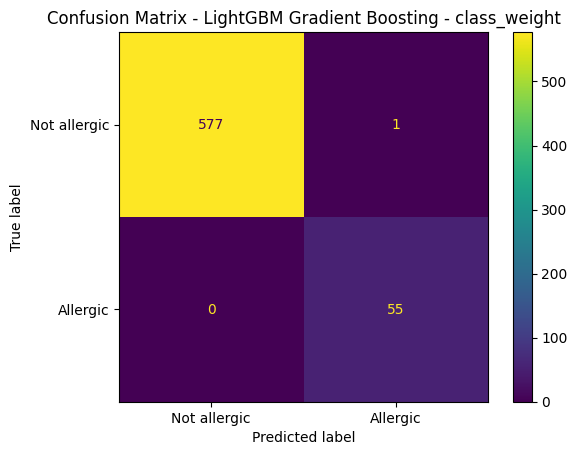

In [62]:
best_model_name = validation_results.iloc[0]["model"]
best_threshold = thresholds[best_model_name]

print("Best model:", best_model_name)
print("Best validation threshold:", round(best_threshold, 4))

final_model = clone(models[best_model_name])
final_model.fit(X_trainval, y_trainval)

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

test_metrics = evaluate_at_threshold(y_test, test_prob, best_threshold)
print("Final test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print()
print("Classification report:")
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay(cm, display_labels=["Not allergic", "Allergic"]).plot(values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 9. Interpretability: feature importance and local explanation

For tree-based models, the notebook shows feature importance. For Logistic Regression, it shows coefficient strength. The local explanation function shows which features pushed one prediction upward the most.

,feature,importance
1,num__weight_kg,57
314,reactions_tfidf__hypersensitivity,50
376,reactions_tfidf__rash,50
288,reactions_tfidf__erythema,50
379,reactions_tfidf__reaction,48
372,reactions_tfidf__pruritus,48
386,reactions_tfidf__somnolence,44
391,reactions_tfidf__syndrome,33
284,reactions_tfidf__dyspnoea,32
229,reactions_tfidf__appetite,31


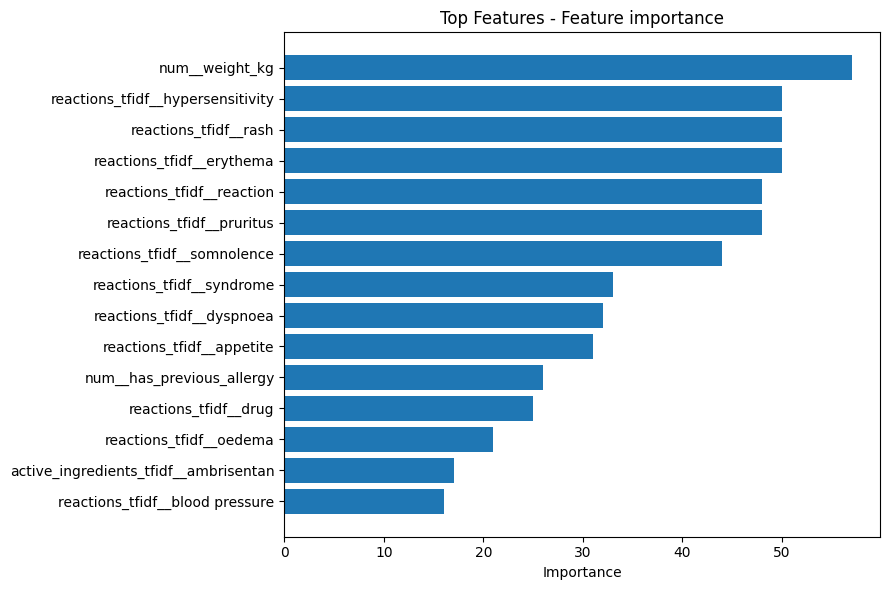

In [63]:
def get_feature_names_from_pipeline(model) -> np.ndarray:
    prep = model.named_steps["prep"]
    try:
        return prep.get_feature_names_out()
    except Exception:
        return np.array([f"feature_{i}" for i in range(prep.transform(X_train.iloc[:1]).shape[1])])

feature_names = get_feature_names_from_pipeline(final_model)
clf = final_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importance_values = clf.feature_importances_
    importance_title = "Feature importance"
elif hasattr(clf, "coef_"):
    importance_values = np.abs(clf.coef_[0])
    importance_title = "Absolute coefficient strength"
else:
    importance_values = np.zeros(len(feature_names))
    importance_title = "Feature score"

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(9, 6))
top_imp = feature_importance.head(15).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title(f"Top Features - {importance_title}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [64]:
def explain_prediction(row: pd.Series, top_n: int = 10) -> pd.DataFrame:
    """Simple local explanation for one row.

    For Logistic Regression, it uses coefficient * transformed feature value.
    For tree models, it falls back to global feature importance for active features.
    For stronger local explanations, use the optional SHAP cell below.
    """
    row_df = pd.DataFrame([row])
    x_trans = final_model.named_steps["prep"].transform(row_df)
    if hasattr(x_trans, "toarray"):
        x_dense = x_trans.toarray()[0]
    else:
        x_dense = np.asarray(x_trans)[0]

    clf = final_model.named_steps["clf"]
    if hasattr(clf, "coef_"):
        values = clf.coef_[0] * x_dense
        label = "local_contribution"
    elif hasattr(clf, "feature_importances_"):
        values = clf.feature_importances_ * np.abs(x_dense)
        label = "importance_x_feature_value"
    else:
        values = np.abs(x_dense)
        label = "active_feature_strength"

    explanation = pd.DataFrame({
        "feature": feature_names,
        label: values,
    })
    explanation["abs_value"] = explanation[label].abs()
    return explanation.sort_values("abs_value", ascending=False).drop(columns="abs_value").head(top_n)

# Example explanation for one test row.
example_index = X_test.index[0]
example_row = X_test.loc[example_index]
example_risk = final_model.predict_proba(pd.DataFrame([example_row]))[:, 1][0]
print("Example drug:", example_row.get("drug_name", "unknown"))
print("Predicted allergy risk:", round(float(example_risk), 4))
display(explain_prediction(example_row, top_n=10))

Example drug: lansoprazole
Predicted allergy risk: 0.0042


,feature,importance_x_feature_value
1,num__weight_kg,16.277822
4,num__is_serious,11.855359
8,cat__drug_role_concomitant,8.000000
2,num__gender_code,7.758514
3,num__has_previous_allergy,3.504346
0,num__age_years,3.114452
221,reactions_tfidf__abnormal,0.356813
286,reactions_tfidf__epistaxis,0.000000
285,reactions_tfidf__dysuria,0.000000
284,reactions_tfidf__dyspnoea,0.000000


In [65]:
# Optional SHAP explanations. This may take a little time.
# It works best for the selected LightGBM/Random Forest model.
RUN_SHAP = False

if RUN_SHAP:
    import shap

    sample = X_test.sample(min(100, len(X_test)), random_state=RANDOM_STATE)
    sample_trans = final_model.named_steps["prep"].transform(sample)
    if hasattr(sample_trans, "toarray"):
        sample_dense = sample_trans.toarray()
    else:
        sample_dense = np.asarray(sample_trans)

    clf = final_model.named_steps["clf"]
    explainer = shap.Explainer(clf, sample_dense, feature_names=feature_names)
    shap_values = explainer(sample_dense)
    shap.plots.beeswarm(shap_values, max_display=15)

## 10. Multi-drug input handling

The system accepts a list of drugs and predicts risk for each one independently.

In [66]:
def most_common_value(series: pd.Series, default="unknown"):
    s = series.dropna()
    if len(s) == 0:
        return default
    return s.mode().iloc[0]


def build_default_context() -> dict:
    context = {}
    for col in X.columns:
        if col in numeric_features:
            context[col] = float(X[col].median())
        else:
            context[col] = most_common_value(X[col], "unknown")
    return context

DEFAULT_CONTEXT = build_default_context()


def build_drug_row(drug_name: str, patient_context: dict | None = None) -> pd.Series:
    row = DEFAULT_CONTEXT.copy()

    # Use known dataset info for the drug if available.
    matches = X[X["drug_name"].astype(str).str.lower().str.strip() == str(drug_name).lower().strip()]
    if len(matches) > 0:
        for col in ["drug_name", "active_ingredients", "drug_role"]:
            if col in X.columns:
                row[col] = most_common_value(matches[col], row.get(col, "unknown"))
    else:
        row["drug_name"] = str(drug_name).lower().strip()
        if "active_ingredients" in row:
            row["active_ingredients"] = "unknown"

    # Patient/context values override defaults.
    if patient_context:
        for key, value in patient_context.items():
            if key in row:
                if isinstance(value, str):
                    row[key] = value.lower().strip()
                else:
                    row[key] = value

    return pd.Series(row)


def predict_multiple_drugs(drug_names: list[str], patient_context: dict | None = None) -> pd.DataFrame:
    rows = [build_drug_row(drug, patient_context) for drug in drug_names]
    input_df = pd.DataFrame(rows)[X.columns]

    risks = final_model.predict_proba(input_df)[:, 1]
    preds = (risks >= best_threshold).astype(int)

    result = pd.DataFrame({
        "drug_name": drug_names,
        "allergy_risk": risks,
        "predicted_allergic": preds,
    })
    result["risk_label"] = np.where(result["predicted_allergic"] == 1, "High risk", "Lower risk")
    return result.sort_values("allergy_risk", ascending=False)

# Example:
predict_multiple_drugs(["Ibuprofen", "Doxycycline Hyclate", "Boniva"])

,drug_name,allergy_risk,predicted_allergic,risk_label
0,Ibuprofen,0.004678,0,Lower risk
1,Doxycycline Hyclate,0.004647,0,Lower risk
2,Boniva,0.004647,0,Lower risk


## 11. Model monitoring and alert system

This section detects two issues:

1. **Performance drop** when labeled new data is available.
2. **Data drift** when new data distribution changes compared with training data.

In [67]:
def compute_performance_metrics(y_true, y_prob, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }


def performance_alert(metrics: dict, min_accuracy: float = 0.90, min_recall: float = 0.80) -> list[str]:
    alerts = []
    if metrics["accuracy"] < min_accuracy:
        alerts.append(f"Accuracy dropped below threshold: {metrics['accuracy']:.3f} < {min_accuracy}")
    if metrics["recall"] < min_recall:
        alerts.append(f"Recall dropped below threshold: {metrics['recall']:.3f} < {min_recall}")
    return alerts


def psi(expected, actual, bins: int = 10) -> float:
    """Population Stability Index for numeric drift."""
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    if len(expected) == 0 or len(actual) == 0:
        return np.nan

    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 3:
        return 0.0

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 0.0001, expected_counts)
    actual_counts = np.where(actual_counts == 0, 0.0001, actual_counts)

    return float(np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts)))


def categorical_drift_score(expected, actual) -> float:
    """Simple total variation distance for categorical drift."""
    expected_dist = pd.Series(expected).fillna("unknown").astype(str).value_counts(normalize=True)
    actual_dist = pd.Series(actual).fillna("unknown").astype(str).value_counts(normalize=True)
    all_keys = expected_dist.index.union(actual_dist.index)
    return float(0.5 * np.abs(expected_dist.reindex(all_keys, fill_value=0) - actual_dist.reindex(all_keys, fill_value=0)).sum())


def data_drift_report(baseline_df: pd.DataFrame, new_df: pd.DataFrame, drift_threshold: float = 0.20) -> pd.DataFrame:
    rows = []

    for col in numeric_features:
        if col in baseline_df.columns and col in new_df.columns:
            score = psi(baseline_df[col], new_df[col])
            rows.append({
                "feature": col,
                "type": "numeric",
                "drift_score": score,
                "alert": bool(score > drift_threshold) if not np.isnan(score) else False,
            })

    for col in categorical_features + text_features:
        if col in baseline_df.columns and col in new_df.columns:
            score = categorical_drift_score(baseline_df[col], new_df[col])
            rows.append({
                "feature": col,
                "type": "categorical/text",
                "drift_score": score,
                "alert": score > drift_threshold,
            })

    return pd.DataFrame(rows).sort_values("drift_score", ascending=False)


def monitor_new_batch(new_data: pd.DataFrame, true_labels: pd.Series | None = None) -> dict:
    new_data_clean = clean_data(new_data)
    new_X = new_data_clean[X.columns]
    new_prob = final_model.predict_proba(new_X)[:, 1]

    output = {}
    if true_labels is not None:
        metrics = compute_performance_metrics(true_labels.astype(int), new_prob, best_threshold)
        output["metrics"] = metrics
        output["performance_alerts"] = performance_alert(metrics)

    drift = data_drift_report(X_train, new_X)
    output["drift_report"] = drift
    output["drift_alerts"] = drift[drift["alert"] == True]
    return output

# Example monitoring using the test set as a fake new batch.
monitoring_example = monitor_new_batch(X_test.copy(), y_test.copy())
print("Performance alerts:", monitoring_example.get("performance_alerts", []))
display(monitoring_example["drift_report"].head(10))

Performance alerts: []


,feature,type,drift_score,alert
10,reactions,categorical/text,0.527195,True
8,drug_name,categorical/text,0.504852,True
9,active_ingredients,categorical/text,0.253103,True
6,drug_role,categorical/text,0.029452,False
5,gender,categorical/text,0.027420,False
1,weight_kg,numeric,0.015840,False
7,previous_allergic_reactions,categorical/text,0.014444,False
0,age_years,numeric,0.004747,False
2,gender_code,numeric,0.000026,False
3,has_previous_allergy,numeric,0.000000,False


In [68]:
# Save useful outputs.
validation_results.to_csv("model_validation_comparison.csv", index=False)
cv_results.to_csv("model_cv_results.csv", index=False)
joblib.dump({
    "model": final_model,
    "threshold": best_threshold,
    "model_name": best_model_name,
    "use_reaction_features": USE_REACTION_FEATURES,
    "columns": list(X.columns),
}, "best_drug_allergy_model.joblib")

print("Saved: model_validation_comparison.csv")
print("Saved: model_cv_results.csv")
print("Saved: best_drug_allergy_model.joblib")

Saved: model_validation_comparison.csv
Saved: model_cv_results.csv
Saved: best_drug_allergy_model.joblib


## 12. Summary

The final system now has:

- Imbalance handling.
- Correct train/validation/test split.
- K-Fold Cross-Validation.
- Validation threshold tuning for high recall.
- Final test-only evaluation.
- Model comparison.
- Confusion matrix, accuracy, recall, and other metrics.
- Feature importance and optional SHAP explanations.
- Multi-drug prediction.
- Monitoring for performance degradation and data drift.